# Combine steric + BPR + Pair to infer sea level



In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.io import loadmat

In [107]:

#N280
# bprfile = '/home/jupyter-mrayson/data/SWOT_Cruise/FV01/RBRqu/[BB23]_[BB23_REC]_[W310]_[48]_[RBRquartz TP]_[213895]_[no_outfile_append]_corrected.nc'
# bprfile = '/home/jupyter-ubuntu/data/SWOT_Cruise/RBRqu/BPR_N280_corrected.mat'
# bprfile = '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_linear_calibration.nc'
# bprfile = '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_nonlinear_calibration.nc'
# bprfile = '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_FES2022_calibration.nc'
# bprfile = '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_W310S245_calibration.nc'
bprfile = '../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_W310S245_Tcalibration.nc'

# Use the ADCP bottom pressure
# basedir2 = '/home/jupyter-ubuntu/data/SWOT_Cruise/FV01/Longranger/'
# bprfile = f'{basedir2}/[BB23]_[BB23_REC]_[N280]_[594]_[Longranger]_[24613]_[no_outfile_append].nc'

stericfile = '~/data/ProjectsActive/SWOT_NAust/DATA/mooring_steric_ssh_N280_v4.nc'
pairfile = '~/data/ProjectsActive/SWOT_NAust/DATA/Australia_Prelude_09-08-2023_0503.csv'

outfile = '~/data/ProjectsActive/SWOT_NAust/DATA/mooring_sealevel_N280_v8.nc'

t1,t2 = '2023-04-22 00:00:00','2023-06-01 00:00:00'

In [108]:
# Load the steric height
ds_sh = xr.open_dataset(stericfile)
ds_sh

<xarray.Dataset> Size: 13MB
Dimensions:         (time: 57600, z_nom: 27)
Coordinates:
  * time            (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:...
  * z_nom           (z_nom) float64 216B -268.8 -263.8 -258.8 ... -28.75 -15.35
    lat_nom         float64 8B ...
    lon_nom         float64 8B ...
    name            <U6 24B ...
Data variables:
    eta_steric      (time) float64 461kB ...
    rho_pr          (z_nom, time) float64 12MB ...
    rho_background  (z_nom) float64 216B ...
Attributes:
    original file:  [BB23]_[BB23_REC]_[N280]_[multi(27)_nominal_instrument_he...

In [109]:
# Load the bottom pressure from the RBR
ds = xr.open_dataset(bprfile)
ds_bpr = ds.isel(time=slice(None,None,16)).sel(time=slice(t1,t2))
# Interpolate onto the steric height 
da_bpr_60s = ds_bpr['BPR_Pressure'].resample(time='60s').mean()
ds_bpr


<xarray.Dataset> Size: 51MB
Dimensions:          (time: 1580993)
Coordinates:
  * time             (time) datetime64[ns] 13MB 2023-05-13T15:24:00 ... 2023-...
    lat_nom          float64 8B ...
    lon_nom          float64 8B ...
    z_nom            float64 8B ...
Data variables:
    BPR_Pressure     (time) float64 13MB ...
    Temperature      (time) float64 13MB ...
    BPR_Temperature  (time) float64 13MB ...
Attributes: (12/38)
    title:                           Measured data from an RBR Data Logger
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          
    project:                         
    history:                         
    ...                              ...
    process_level:                   Process Level 0
    is_profile_data:                 0
    rawfile:                         ../../../SWOT_Cruise/RBRqu/N280_RBRQu_21...
    Temperature info:                Temperature calibrations: lag 5310664, p...
    Pressure info (1):               Pressure calibrations:  p0 0.00346384572...
    Pressure info (2):               Pressure (temperature) calibrations:  Kp...

In [110]:
da_bpr = da_bpr_60s.interp({'time':ds_sh.time.values})
da_bpr

<xarray.DataArray 'BPR_Pressure' (time: 57600)> Size: 461kB
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
    lat_nom  float64 8B ...
    lon_nom  float64 8B ...
    z_nom    float64 8B ...
  * time     (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:59:00

In [111]:
# # Load the bottom pressure from the ACDP
# ds = xr.open_dataset(bprfile)
# da_bpr = ds['pressure'].interp({'time':ds_sh.time.values})


In [112]:
da_bpr.mean()

<xarray.DataArray 'BPR_Pressure' ()> Size: 8B
array(276.04102061)
Coordinates:
    lat_nom  float64 8B ...
    lon_nom  float64 8B ...
    z_nom    float64 8B ...

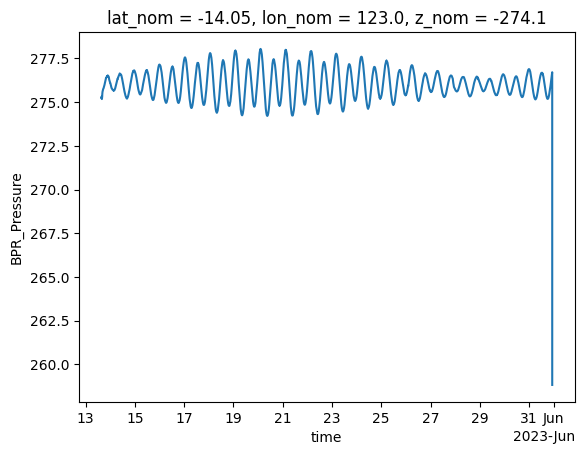

In [113]:
da_bpr.plot()

In [114]:
# Load the air pressure
#pd.read_csv?
df = pd.read_csv(pairfile, header=2, index_col='UTC', parse_dates=True)
da_pair = xr.DataArray(df['BarometricPressure/mbar_10min_Mean']).rename({'UTC':'time'})
da_pair.name = 'Pair'
da_pair

<xarray.DataArray 'Pair' (time: 19699)> Size: 158kB
array([1000.90710714, 1000.87490358, 1000.88536667, ..., 1008.65385   ,
       1008.46893333, 1008.31296667])
Coordinates:
  * time     (time) datetime64[ns] 158kB 2023-03-22T21:00:00 ... 2023-08-09T0...

In [115]:
# Interpolate onto the steric height points
da_pair_60s = da_pair.interp({'time':ds_sh.time.values})

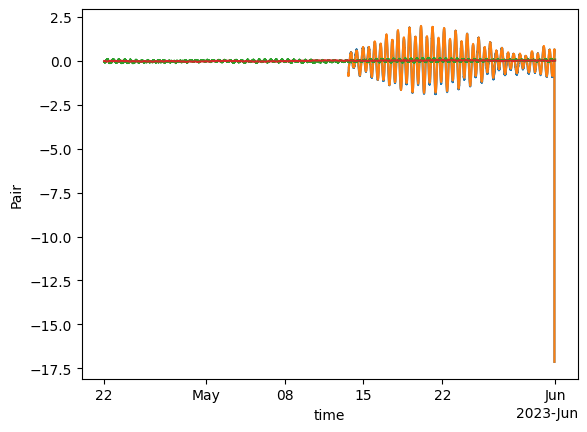

In [116]:
# Calculate sea level
g = 9.81
rho0 = 1024

pb_pr = da_bpr - da_bpr.mean()
pb_pr *= 10000. # decibars to pascals

pa_pr = da_pair_60s - da_pair_60s.mean()
pa_pr *= 100 # hectopascals to pascals

#p_steric = -1*g*rho0 * ds_sh['eta_steric'] # Steric height is stored with a different sign
p_steric = g*rho0 * ds_sh['eta_steric'] # v4 Steric height is stored correct sign

p_steric = p_steric.drop_vars(['lon_nom','lat_nom'])
cff = np.power(g*rho0, -1)
eta = cff * (pb_pr - pa_pr - p_steric)

plt.figure()
eta.plot()
(pb_pr*cff).plot()
(p_steric*cff).plot()
(pa_pr*cff).plot()

In [81]:
import pyTMD
pyTMD.__version__

'2.2.8'

In [82]:
from nwatides import fes, hanalysis

In [83]:
#pip install pytmd==2.2.4

In [84]:
%%time
# Get the tides
ilon = np.array([ds_sh.lon_nom.values])
ilat = np.array([ds_sh.lat_nom.values])
time = pd.DatetimeIndex(ds_sh.time.values)
constituents, minor = None, None
eta_tide = fes.tidal_prediction(ilon, ilat, time, 'z')
eta_tide

not broadcasting because len(lon)==len(lat)
Using FES2022...
CPU times: user 2min 6s, sys: 37.9 s, total: 2min 44s
Wall time: 2min 43s


<xarray.Dataset> Size: 922kB
Dimensions:  (lon: 1, lat: 1, time: 57600)
Coordinates:
  * lon      (lon) float64 8B 123.0
  * lat      (lat) float64 8B -14.05
  * time     (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:59:00
Data variables:
    z_tide   (lon, time) float64 461kB -0.5342 -0.5169 -0.4994 ... 1.146 1.148

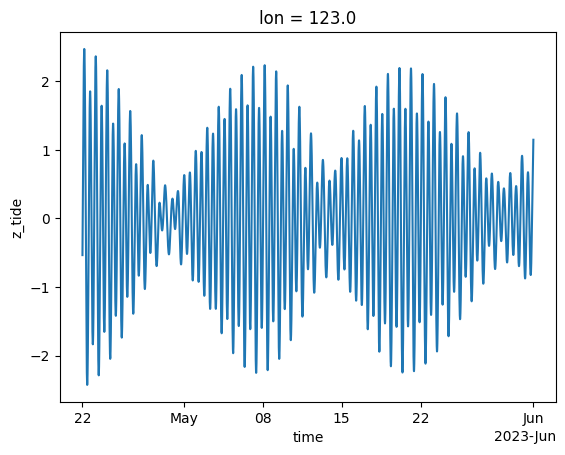

In [117]:
eta_tide['z_tide'].plot()

(-3.0, 3.0)

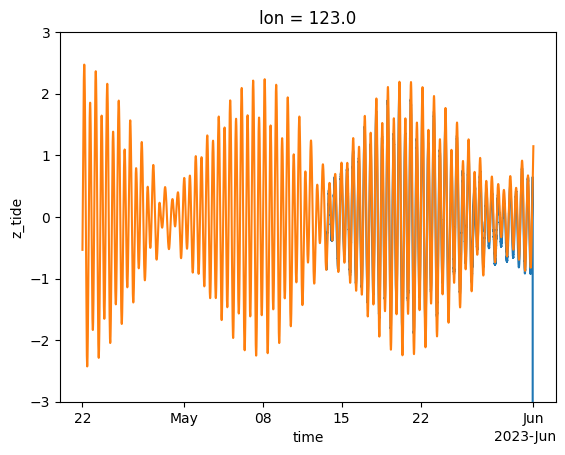

In [118]:
eta.plot()
eta_tide['z_tide'].plot()
plt.ylim(-3,3)

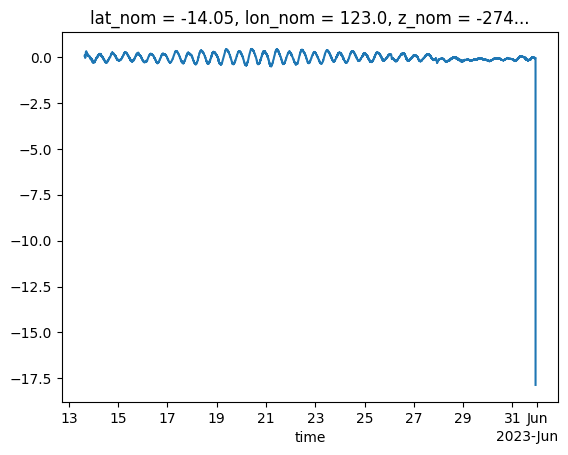

In [119]:
(eta - eta_tide['z_tide']).plot()

(-1.0, 1.0)

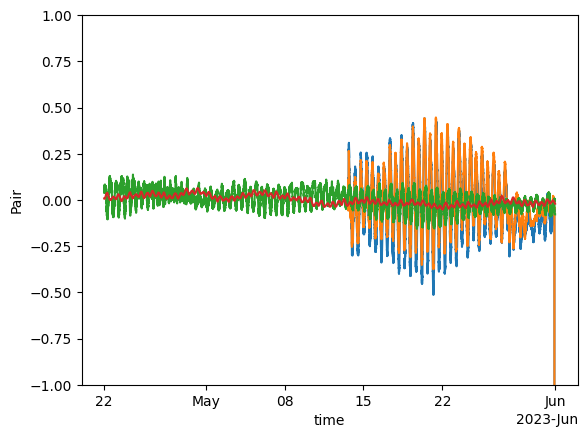

In [120]:
(eta - eta_tide['z_tide']).plot()
(pb_pr*cff- eta_tide['z_tide']).plot()
(-p_steric*cff).plot()
(-pa_pr*cff).plot()
plt.ylim(-1,1)

In [121]:
eta_tide

<xarray.Dataset> Size: 922kB
Dimensions:  (lon: 1, lat: 1, time: 57600)
Coordinates:
  * lon      (lon) float64 8B 123.0
  * lat      (lat) float64 8B -14.05
  * time     (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:59:00
Data variables:
    z_tide   (lon, time) float64 461kB -0.5342 -0.5169 -0.4994 ... 1.146 1.148

In [122]:
# Let's export everything as sea level (units m)
ds_ssh = xr.Dataset(
    {'eta':eta,
    'eta_tide_fes':eta_tide['z_tide'],
    'eta_steric':p_steric*cff,
    'eta_a':pa_pr*cff,
    'eta_b':pb_pr*cff,
    },
)
ds_ssh

<xarray.Dataset> Size: 3MB
Dimensions:       (time: 57600, lon: 1)
Coordinates:
    lat_nom       float64 8B -14.05
    lon_nom       float64 8B 123.0
    z_nom         float64 8B -274.1
  * time          (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:59:00
    name          <U6 24B 'rho_pr'
  * lon           (lon) float64 8B 123.0
Data variables:
    eta           (time) float64 461kB nan nan nan nan nan ... nan nan nan nan
    eta_tide_fes  (lon, time) float64 461kB -0.5342 -0.5169 ... 1.146 1.148
    eta_steric    (time) float64 461kB -0.05207 -0.06148 ... 0.07824 0.07824
    eta_a         (time) float64 461kB -0.008518 -0.008493 ... 0.02031 0.02036
    eta_b         (time) float64 461kB nan nan nan nan nan ... nan nan nan nan

In [123]:
ds_ssh['eta'].attrs = {
    'long_name':'total sea surface height anomaly',
    'units':'m',
    'comments':'eta = (eta_b - eta_a - eta_steric)/(rho0*g)'
}
ds_ssh['eta_a'].attrs = {
    'long_name':'atmospheric pressure contribution to sea surface height anomaly',
    'units':'m',
    'raw_data':pairfile
}

ds_ssh['eta_b'].attrs = {
    'long_name':'bottom pressure contribution to sea surface height anomaly',
    'units':'m',
    'raw_data':bprfile
}

ds_ssh['eta_steric'].attrs = {
    'long_name':'steric height contribution to sea surface height anomaly',
    'units':'m',
    'raw_data':stericfile
}

ds_ssh['eta_tide_fes'].attrs = {
    'long_name':'tidal contribution to sea surface height anomaly',
    'units':'m',
    #'raw_data':'FES2014',
    'raw_data':'FES2022',
}
ds_ssh

<xarray.Dataset> Size: 3MB
Dimensions:       (time: 57600, lon: 1)
Coordinates:
    lat_nom       float64 8B -14.05
    lon_nom       float64 8B 123.0
    z_nom         float64 8B -274.1
  * time          (time) datetime64[ns] 461kB 2023-04-22 ... 2023-05-31T23:59:00
    name          <U6 24B 'rho_pr'
  * lon           (lon) float64 8B 123.0
Data variables:
    eta           (time) float64 461kB nan nan nan nan nan ... nan nan nan nan
    eta_tide_fes  (lon, time) float64 461kB -0.5342 -0.5169 ... 1.146 1.148
    eta_steric    (time) float64 461kB -0.05207 -0.06148 ... 0.07824 0.07824
    eta_a         (time) float64 461kB -0.008518 -0.008493 ... 0.02031 0.02036
    eta_b         (time) float64 461kB nan nan nan nan nan ... nan nan nan nan

In [124]:
ds_ssh.to_netcdf(outfile)
outfile

'~/data/ProjectsActive/SWOT_NAust/DATA/mooring_sealevel_N280_v8.nc'

In [125]:
timeraw = datenum_to_datetime64_ns(mattimeraw[:,0])
da_p2 = xr.DataArray(pres_raw[:,0], coords=dict(time=timeraw))
da_p2

NameError: name 'datenum_to_datetime64_ns' is not defined

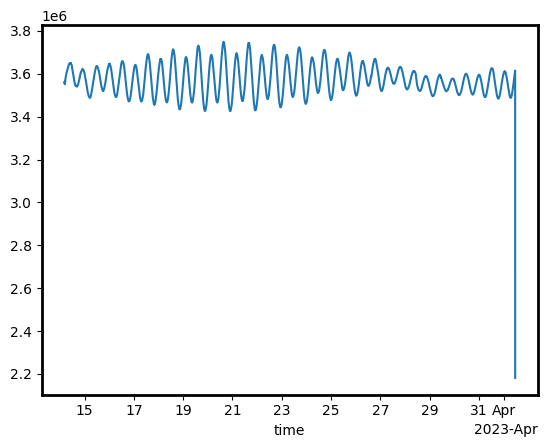

In [50]:
da_p_1Hz = da_p2.isel(time=slice(None,None,16))#.sel(time=slice(t1,t2))
da_bpr_60s = da_p_1Hz.resample(time='60s').mean()
da_bpr_60s.plot()

In [67]:
ds = da_bpr_60s
new_start = da_p.time[0]
offset = new_start - ds.time[0]
shifted_ds = ds.assign_coords(time=ds.time + offset)


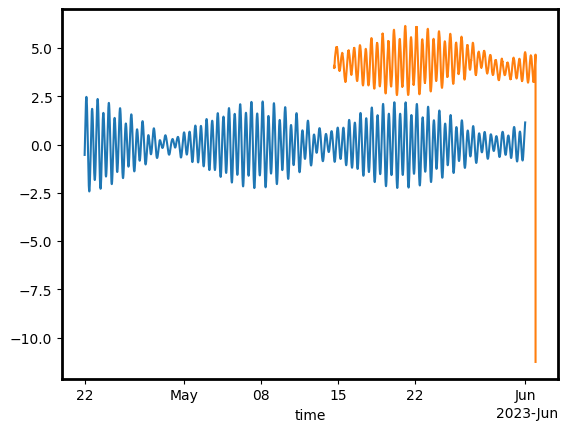

In [71]:
scale = 0.9e5
offset = 35.5
eta_tide['z_tide'].plot()
((shifted_ds/scale)-offset).plot()
# ((da_bpr_60s-offset)/scale).plot()